## 1. Setup and Configuration

In [6]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# =============================================================================
# DIRECTORY PATHS
# =============================================================================
CODE_DIR = Path(r"c:\Users\skazempour\Dropbox\Projects\42 - Machine learning from the crowd\Code")
DATA_DIR = Path(r"c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\csv")

# Input: Merged StockTwits-CRSP data by year
INPUT_FOLDER = DATA_DIR / "merged_with_crsp_mlcrowd"

# Output: Features (consolidated pickle files)
OUTPUT_FOLDER = DATA_DIR / "features_mlcrowd"
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = OUTPUT_FOLDER / "feature_39_disagreement.pkl"

print(f"Input folder: {INPUT_FOLDER}")
print(f"Output folder: {OUTPUT_FOLDER}")
print(f"Output file: {OUTPUT_FILE}")

Input folder: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\csv\merged_with_crsp_mlcrowd
Output folder: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\csv\features_mlcrowd
Output file: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\csv\features_mlcrowd\feature_39_disagreement.pkl


## 2. Load Trading Day Calendar from Fama-French Data

In [7]:
# Download Fama-French daily factors to get official trading day calendar
import pandas_datareader as pdr

print("Loading Fama-French data for trading day calendar...")
try:
    # Download FF3 daily factors (has all trading days)
    ff_data = pdr.data.DataReader('F-F_Research_Data_Factors_daily', 'famafrench', start='2010')[0]
    
    # Extract trading days
    ALL_TRADING_DAYS = pd.to_datetime(ff_data.index)
    print(f"✓ Loaded {len(ALL_TRADING_DAYS):,} trading days from Fama-French")
    print(f"  Date range: {ALL_TRADING_DAYS.min()} to {ALL_TRADING_DAYS.max()}")
    
except Exception as e:
    print(f"Warning: Could not download FF data: {e}")
    print("Will extract trading days from CRSP-merged data instead")
    ALL_TRADING_DAYS = None

Loading Fama-French data for trading day calendar...


C:\Users\skazempour\AppData\Local\Temp\ipykernel_3320\3606649663.py:7: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_data = pdr.data.DataReader('F-F_Research_Data_Factors_daily', 'famafrench', start='2010')[0]


✓ Loaded 4,002 trading days from Fama-French
  Date range: 2010-01-04 00:00:00 to 2025-11-28 00:00:00


## 3. Load Sample Data for Development

In [8]:
# Get list of available files
files = sorted([f for f in os.listdir(INPUT_FOLDER) if f.endswith('.csv')])
print(f"Available files: {len(files)}")
print(f"Files: {files}")

# Load most recent year for development
if files:
    sample_file = INPUT_FOLDER / files[-1]
    print(f"\nLoading sample file for testing: {sample_file.name}")
    
    df_sample = pd.read_csv(sample_file)
    df_sample['date'] = pd.to_datetime(df_sample['date'])
    
    print(f"\nShape: {df_sample.shape}")
    print(f"Date range: {df_sample['date'].min()} to {df_sample['date'].max()}")
    print(f"Unique symbols: {df_sample['symbol'].nunique():,}")
    print(f"\nColumns: {list(df_sample.columns)}")

Available files: 15
Files: ['stocktwits_crsp_2010.csv', 'stocktwits_crsp_2011.csv', 'stocktwits_crsp_2012.csv', 'stocktwits_crsp_2013.csv', 'stocktwits_crsp_2014.csv', 'stocktwits_crsp_2015.csv', 'stocktwits_crsp_2016.csv', 'stocktwits_crsp_2017.csv', 'stocktwits_crsp_2018.csv', 'stocktwits_crsp_2019.csv', 'stocktwits_crsp_2020.csv', 'stocktwits_crsp_2021.csv', 'stocktwits_crsp_2022.csv', 'stocktwits_crsp_2023.csv', 'stocktwits_crsp_2024.csv']

Loading sample file for testing: stocktwits_crsp_2024.csv

Shape: (7247, 40)
Date range: 2024-01-02 00:00:00 to 2024-01-03 00:00:00
Unique symbols: 1,043

Columns: ['message_id', 'user_id', 'created_at', 'sentiment', 'time', 'hour', 'is_after_hours', 'session', 'date', 'symbol', 'permno', 'prc', 'vol', 'shrout', 'ret', 'ar_dgtw_1', 'ar_dgtw_3', 'ar_dgtw_5', 'ar_dgtw_21', 'ar_dgtw_63', 'ar_capm_1', 'ar_capm_3', 'ar_capm_5', 'ar_capm_21', 'ar_capm_63', 'ar_FF3_1', 'ar_FF3_3', 'ar_FF3_5', 'ar_FF3_21', 'ar_FF3_63', 'ar_FF5_1', 'ar_FF5_3', 'ar_FF5_5'

## 4. Define Feature Calculation Function

In [9]:
def calculate_disagreement_index(df, trading_days=None):
    """
    Calculate disagreement index for each stock-day.
    
    Disagreement Index = 1 - |N_Bull - N_Bear| / (N_Bull + N_Bear)
    
    Parameters:
    -----------
    df : pd.DataFrame
        Merged StockTwits-CRSP data with columns: symbol, date, sentiment
    trading_days : pd.DatetimeIndex or None
        Complete set of trading days for creating sparse grid
    
    Returns:
    --------
    pd.DataFrame : Features indexed by (symbol, date) with column 'disagreement_index'
    """
    
    # Ensure required columns exist
    required_cols = ['symbol', 'date', 'sentiment']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    # Convert dates
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    
    # Count bullish and bearish tweets per stock-day
    sentiment_counts = df.groupby(['symbol', 'date', 'sentiment']).size().unstack(fill_value=0)
    
    # Ensure both columns exist
    if 'Bullish' not in sentiment_counts.columns:
        sentiment_counts['Bullish'] = 0
    if 'Bearish' not in sentiment_counts.columns:
        sentiment_counts['Bearish'] = 0
    
    sentiment_counts = sentiment_counts.reset_index()
    
    # Calculate disagreement index
    total = sentiment_counts['Bullish'] + sentiment_counts['Bearish']
    abs_diff = np.abs(sentiment_counts['Bullish'] - sentiment_counts['Bearish'])
    
    sentiment_counts['disagreement_index'] = np.where(
        total > 0,
        1 - (abs_diff / total),
        np.nan  # NaN when no tweets (undefined)
    )
    
    # Create complete trading day grid
    all_symbols = sorted(df['symbol'].unique())
    
    if trading_days is not None:
        data_start = df['date'].min()
        data_end = df['date'].max()
        all_trading_days = trading_days[(trading_days >= data_start) & (trading_days <= data_end)]
    else:
        all_trading_days = sorted(df['date'].unique())
    
    complete_grid = pd.MultiIndex.from_product(
        [all_symbols, all_trading_days],
        names=['symbol', 'date']
    ).to_frame(index=False)
    
    # Merge with complete grid
    results = complete_grid.merge(
        sentiment_counts[['symbol', 'date', 'disagreement_index']], 
        on=['symbol', 'date'], 
        how='left'
    )
    
    # Set index
    results = results.set_index(['symbol', 'date'])
    
    return results

## 5. Test Function on Sample Data

In [10]:
# Test on a single stock from sample data
test_symbol = df_sample['symbol'].value_counts().head(1).index[0]
df_test = df_sample[df_sample['symbol'] == test_symbol].copy()

print(f"Testing with symbol: {test_symbol}")
print(f"Date range: {df_test['date'].min()} to {df_test['date'].max()}")
print(f"Total tweets: {len(df_test):,}")

# Calculate features
features_test = calculate_disagreement_index(
    df_test, 
    trading_days=ALL_TRADING_DAYS
)

print(f"\nFeatures shape: {features_test.shape}")
print(f"Feature columns: {list(features_test.columns)}")

features_test.head(20)

Testing with symbol: MARA
Date range: 2024-01-02 00:00:00 to 2024-01-03 00:00:00
Total tweets: 414

Features shape: (2, 1)
Feature columns: ['disagreement_index']


disagreement_index
symbol date                          
MARA   2024-01-02            0.219451
       2024-01-03            0.769231

## 6. Visualize Feature

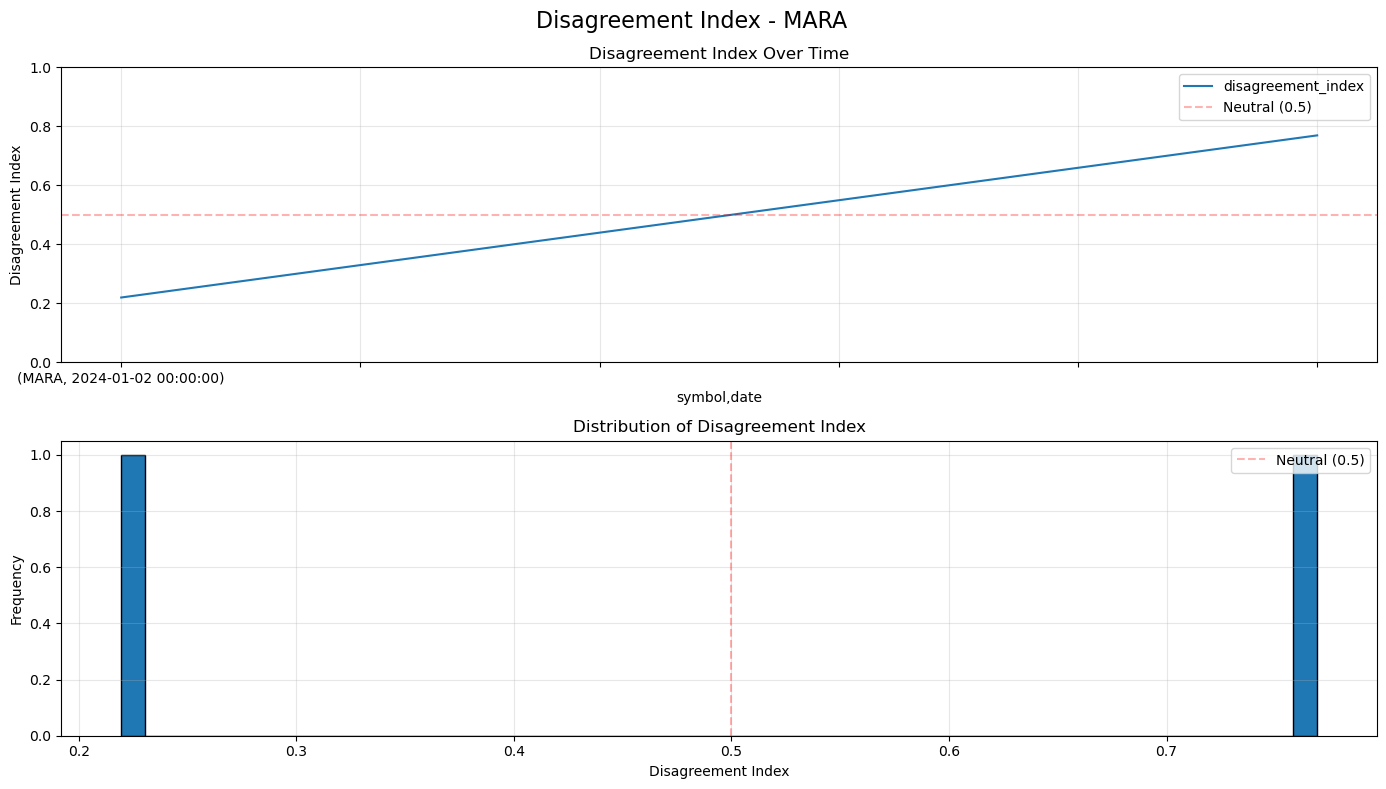


✓ Visualization complete


In [11]:
# Visualize disagreement index
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle(f'Disagreement Index - {test_symbol}', fontsize=16)

# Plot 1: Time series
features_test['disagreement_index'].plot(ax=axes[0], title='Disagreement Index Over Time')
axes[0].axhline(y=0.5, color='r', linestyle='--', alpha=0.3, label='Neutral (0.5)')
axes[0].set_ylabel('Disagreement Index')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Distribution
features_test['disagreement_index'].dropna().hist(bins=50, ax=axes[1], edgecolor='black')
axes[1].axvline(x=0.5, color='r', linestyle='--', alpha=0.3, label='Neutral (0.5)')
axes[1].set_xlabel('Disagreement Index')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Disagreement Index')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete")

## 7. Feature Statistics

In [12]:
# Display summary statistics
print("Disagreement Index Statistics:")
print("=" * 80)
print(features_test['disagreement_index'].describe())

print("\nValue Ranges:")
print(f"  Minimum: {features_test['disagreement_index'].min():.4f}")
print(f"  Maximum: {features_test['disagreement_index'].max():.4f}")
print(f"  Mean: {features_test['disagreement_index'].mean():.4f}")
print(f"  Median: {features_test['disagreement_index'].median():.4f}")

# Check extremes
print("\nInterpretation:")
high_disagreement = (features_test['disagreement_index'] > 0.8).sum()
low_disagreement = (features_test['disagreement_index'] < 0.2).sum()
print(f"  High disagreement days (>0.8): {high_disagreement} ({high_disagreement/len(features_test)*100:.1f}%)")
print(f"  Low disagreement days (<0.2): {low_disagreement} ({low_disagreement/len(features_test)*100:.1f}%)")

Disagreement Index Statistics:
count    2.000000
mean     0.494341
std      0.388753
min      0.219451
25%      0.356896
50%      0.494341
75%      0.631786
max      0.769231
Name: disagreement_index, dtype: float64

Value Ranges:
  Minimum: 0.2195
  Maximum: 0.7692
  Mean: 0.4943
  Median: 0.4943

Interpretation:
  High disagreement days (>0.8): 0 (0.0%)
  Low disagreement days (<0.2): 0 (0.0%)


## 8. Check for Data Quality Issues

In [13]:
# Check for missing values
print("Missing Values:")
print("=" * 80)
missing = features_test['disagreement_index'].isnull().sum()
missing_pct = (missing / len(features_test)) * 100
print(f"Missing count: {missing:,} ({missing_pct:.2f}%)")
print("Note: Missing values occur on trading days with no tweets (expected)")

# Check for invalid values
print("\nValue Validation:")
print("=" * 80)
invalid = ((features_test['disagreement_index'] < 0) | (features_test['disagreement_index'] > 1)).sum()
if invalid > 0:
    print(f"⚠️ WARNING: {invalid} values outside [0, 1] range!")
else:
    print("✓ All values within valid range [0, 1]")

# Check for infinite values
inf_count = np.isinf(features_test['disagreement_index']).sum()
if inf_count > 0:
    print(f"⚠️ WARNING: {inf_count} infinite values!")
else:
    print("✓ No infinite values found")

Missing Values:
Missing count: 0 (0.00%)
Note: Missing values occur on trading days with no tweets (expected)

Value Validation:
✓ All values within valid range [0, 1]
✓ No infinite values found


## 9. Process All Years and Save Features

In [14]:
# Process all years
all_features = []

for file in tqdm(files, desc="Processing years"):
    file_path = INPUT_FOLDER / file
    year = file.split('_')[-1].replace('.csv', '')
    
    print(f"\n{'='*80}")
    print(f"Processing {file} (Year: {year})")
    print(f"{'='*80}")
    
    # Load data
    df_year = pd.read_csv(file_path)
    df_year['date'] = pd.to_datetime(df_year['date'])
    
    print(f"Loaded {len(df_year):,} rows")
    print(f"Symbols: {df_year['symbol'].nunique():,}")
    print(f"Date range: {df_year['date'].min()} to {df_year['date'].max()}")
    
    # Calculate features
    print("\nCalculating disagreement index...")
    features_year = calculate_disagreement_index(
        df_year,
        trading_days=ALL_TRADING_DAYS
    )
    
    print(f"Features shape: {features_year.shape}")
    print(f"Non-null values: {features_year['disagreement_index'].notna().sum():,}")
    
    all_features.append(features_year)
    
    print(f"✓ Year {year} complete")

# Concatenate all years
print(f"\n{'='*80}")
print("Concatenating all years...")
final_features = pd.concat(all_features, axis=0)

print(f"Final shape: {final_features.shape}")
print(f"Date range: {final_features.index.get_level_values('date').min()} to {final_features.index.get_level_values('date').max()}")
print(f"Unique symbols: {final_features.index.get_level_values('symbol').nunique():,}")
print(f"Non-null values: {final_features['disagreement_index'].notna().sum():,}")

Processing years:   0%|          | 0/15 [00:00<?, ?it/s]


Processing stocktwits_crsp_2010.csv (Year: 2010)
Loaded 11,824 rows
Symbols: 1,698
Date range: 2010-06-02 00:00:00 to 2010-12-31 00:00:00

Calculating disagreement index...
Features shape: (253002, 1)
Non-null values: 8,718
✓ Year 2010 complete

Processing stocktwits_crsp_2011.csv (Year: 2011)
Loaded 34,180 rows
Symbols: 2,536
Date range: 2011-01-03 00:00:00 to 2011-12-30 00:00:00

Calculating disagreement index...
Features shape: (639072, 1)
Non-null values: 24,482
✓ Year 2011 complete

Processing stocktwits_crsp_2012.csv (Year: 2012)
Loaded 80,848 rows
Symbols: 2,557
Date range: 2012-01-03 00:00:00 to 2012-12-31 00:00:00

Calculating disagreement index...
Features shape: (639250, 1)
Non-null values: 32,152
✓ Year 2012 complete

Processing stocktwits_crsp_2013.csv (Year: 2013)
Loaded 463,112 rows
Symbols: 3,328
Date range: 2013-01-02 00:00:00 to 2013-12-31 00:00:00

Calculating disagreement index...
Features shape: (838656, 1)
Non-null values: 105,570
✓ Year 2013 complete

Processing

## 10. Save to Pickle

In [15]:
# Save to pickle
print(f"\nSaving to {OUTPUT_FILE}...")
final_features.to_pickle(OUTPUT_FILE)

# Verify save
file_size_mb = OUTPUT_FILE.stat().st_size / (1024 * 1024)
print(f"✓ Saved successfully")
print(f"  File size: {file_size_mb:.2f} MB")

# Load and verify
print("\nVerifying saved file...")
loaded = pd.read_pickle(OUTPUT_FILE)
print(f"✓ Loaded shape: {loaded.shape}")
print(f"✓ Columns: {list(loaded.columns)}")
print(f"✓ Index levels: {loaded.index.names}")
print(f"✓ Non-null values: {loaded['disagreement_index'].notna().sum():,}")


Saving to c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\csv\features_mlcrowd\feature_39_disagreement.pkl...
✓ Saved successfully
  File size: 151.20 MB

Verifying saved file...
✓ Loaded shape: (13205093, 1)
✓ Columns: ['disagreement_index']
✓ Index levels: ['symbol', 'date']
✓ Non-null values: 3,505,817


## 11. Summary

### Feature Implemented:

**Feature 39: Disagreement Index**
- Formula: $1 - \frac{|N_{Bull} - N_{Bear}|}{N_{Bull} + N_{Bear}}$
- Range: [0, 1]
  - 0 = Complete consensus (all bullish or all bearish)
  - 1 = Maximum disagreement (50/50 split)
- NaN on days with no tweets (expected sparse data behavior)

**Use Cases:**
- High disagreement may signal uncertainty, upcoming volatility, or information asymmetry
- Low disagreement indicates strong consensus (could be a contrarian signal)
- Can be combined with volume to distinguish between "quiet consensus" vs "loud debate"

**Output:** `feature_39_disagreement.pkl`